# Goal:
The goal of this notebook is to study the convergence of the Mean Variational Error (MVE) vs the number of sequences when the optimization is initialized at a random gate set.

This idea came out after working in the notebook `1q_random_channel_vs_sequences.ipynb`. There, we used the perturbed target initialization. 

The hypothesis is that, to be able to see the phase transition as done in the mGST paper, we need to start far away enough from the target gate set. Besides the reconstruction algorithm, this is basically the only thing missing to have the exact same setup as Fig. 3 in the mGST paper.

If this doesn't work, we would be running out of ideas of why is this phase transition not shown ... so it better work 😳!!!

Date of creation: 04.08.2026

In [40]:
from mGST.utility_functions_comparisons import get_target_operators_gate_set_name, get_compressed_rep_from_mgst_output, kraus_tensor_to_mgst, get_initial_gate_set_for_optimization, get_mgst_tensors_from_psd_representation
from mGST.simulate import apply_noisy_kraus_tensors_to_target_gate_set, get_random_noisy_kraus_tensors_for_gate_set, get_random_gate_set_superop, generate_sequence_indices, run_optimization_workflow
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.visualization import plot_cost_function

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
num_sequences = 100
num_shots = 1000
seq_len_list = [1, 8, 14]
num_qubits = 1
dim = 2 ** num_qubits
state_rank = dim # max
povm_rank = dim # max
kraus_rank = dim**2
num_gates = 3
num_povm = dim
gate_set_name = "1QXYI"
noise_strength = 5e-3

# Noiseless and noisy tensors

In [8]:
target_operators, gate_labels = get_target_operators_gate_set_name(gate_set_name=gate_set_name)

INFO:2026-08-04 17:25:12,830:jax._src.xla_bridge:927: Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-08-04 17:25:12,830 - jax._src.xla_bridge - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:2026-08-04 17:25:12,838:jax._src.xla_bridge:927: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/opt/homebrew/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/lib/libtpu.so' (no such file), '/Users/emiliano.godinez/.pyenv/versions/3.11.10/lib/libtpu.so' (no such file), '/System/Volumes/Preboot/

In [14]:
random_kraus_tensors = get_random_noisy_kraus_tensors_for_gate_set(
    num_gates=num_gates,
    dim=dim,
    rank_kraus=kraus_rank,
    noise_strength=noise_strength,
    seed=42
)

In [16]:
noisy_gate_set_superop = apply_noisy_kraus_tensors_to_target_gate_set(
    kraus_tensors_noisy=random_kraus_tensors,
    target_gate_set=target_operators,
    is_target_vectorized=True,
)

kraus_tensor_noisy, povm_psd_noisy, state_psd_noisy = get_compressed_rep_from_mgst_output(*noisy_gate_set_superop.values(), kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)

In [20]:
# let's get the remaining PSD representations
kraus_target_superop = kraus_tensor_to_mgst(target_operators["kraus"])
# 1. Target
target_gate_set_superops = {
    "kraus": kraus_target_superop,
    "povm": target_operators["povm"],
    "state": target_operators["state"],
}

# 2. Initiallization
init_gate_set_psd = get_initial_gate_set_for_optimization(
    target_superops=target_gate_set_superops,
    kraus_rank=kraus_rank,
    state_rank=state_rank,
    povm_rank=povm_rank
)

init_gate_set_superop = get_mgst_tensors_from_psd_representation(*init_gate_set_psd.values())

# Gathering them all in one place
noisy_gate_set_psd = {
    "kraus": kraus_tensor_noisy,
    "povm": povm_psd_noisy,
    "state": state_psd_noisy,
}

# Optimization

In [38]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.
relative_precision = 1e-11 # decrease by 2 orders of magnitude.
global_gradient_norm_tol = 1e-10 #

tr_schedule_silence = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=False, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad))


optimization_schedule_silence= {
    "kraus": tr_schedule_silence,
    "povm": tr_schedule_silence,
    "state": tr_schedule_silence
}

optimization_options_silence = {
    "schedule": optimization_schedule_silence,
    "num_iterations_outer": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
}
optimization_options_silence

{'schedule': {'kraus': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'povm': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))]),
  'state': OperatorSchedule(items=[OptimizationScheduleItem(start=0, end=19, options=TrustRegionOptions(metric='euclidean', verbose=False, num_iterations=5, radius_init=0.1, max_radius=2.0, quotient_trust=0.125, tol_grad=1e-08, num_iterations_cg=10, theta_cg=1, kappa_cg=0.1, verbose_cg=False))])},
 'num_iterations_outer': 20,
 'relative_precision': 1e-11,
 'global_gradient_norm_tol': 1e-10,

In [60]:
optimization_options_random = optimization_options_silence.copy()
optimization_options_random["num_iterations_outer"] = 30

## Warm-up: 
run a simple optimization with random initialization vs target init.

In [46]:
seeds = [42, 43, 44]
rndm_gate_set_superop = get_random_gate_set_superop(num_gates=num_gates, dim=dim, kraus_rank=kraus_rank, num_povm=dim, seeds=seeds)
rndm_gate_set_psd = get_compressed_rep_from_mgst_output(*rndm_gate_set_superop.values(), kraus_rank=kraus_rank, state_rank=state_rank, povm_rank=povm_rank)
rndm_gate_set_psd_dict = {
    "kraus": rndm_gate_set_psd[0],
    "povm": rndm_gate_set_psd[1],
    "state": rndm_gate_set_psd[2],
}

In [35]:
# to make it fair we use the same indices_dict for both optimizations
indices_dict_fixed = generate_sequence_indices(num_gates=num_gates, num_circuits=num_sequences, seq_len_list=seq_len_list)

In [37]:
opt_result_target_init = run_optimization_workflow(
    num_shots=num_shots,
    init_operators=init_gate_set_psd,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    use_exact_probabilities=False,
    optimization_options=optimization_options_silence,
    warmup_run=False,
    use_log_likelihood=True,
    compute_least_squares=1, # to compute after every operator
    optimization_verbose=False, # we trust it (?)
    indices_dict=indices_dict_fixed
    )

Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
at iteration 0 the new count changed to: 1
at iteration 1 the new count changed to: 2
at iteration 4 the new count changed to: 3
at iteration 10 the new count changed to: 4
at iteration 16 the new count changed to: 5
at iteration 22 the new count changed to: 6
at iteration 29 the new count changed to: 7
at iteration 36 the new count changed to: 8
at iteration 43 the new count changed to: 9
at iteration 50 the new count changed to: 10
at iteration 58 the new count changed to: 11
at iteration 66 the new count changed to: 12
at iteration 74 the new count changed to: 13
at iteration 82 the new count changed to: 14
at iteration 91 the new count changed to: 15
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 5.104362e+04. |r∇f(x)|: 1.011573e-03. Radius: 1.56e-03. Re

In [47]:
opt_result_rndm_init = run_optimization_workflow(
    num_shots=num_shots,
    init_operators=rndm_gate_set_psd_dict,
    operators_psd_true=noisy_gate_set_psd,
    target_superops=target_gate_set_superops,
    use_exact_probabilities=False,
    optimization_options=optimization_options_silence,
    warmup_run=False,
    use_log_likelihood=True,
    compute_least_squares=1, # to compute after every operator
    optimization_verbose=False, # we trust it (?)
    indices_dict=indices_dict_fixed
    )

Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.913667e+04. |r∇f(x)|: 1.579098e+03. Radius: 1.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.829668e+04. |r∇f(x)|: 2.433319e+03. Radius: 2.00e-01. Rejections: 1
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.817560e+04. |r∇f(x)|: 1.671000e-03. Radius: 5.00e-02. Rejections: 1
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.799540e+04. |r∇f(x)|: 2.836987e+00. Radius: 2.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.682901e+04. |r∇f(x)|: 4.787050e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: state 🚀.
Optimization finishe

In [71]:
random_inits = 3

opt_results_random_inits = []
for idx in range(random_inits):
    print(f"*** Running optimization with random initialization {idx+1}/{random_inits} ***")
    opt_result_idx = run_optimization_workflow(
        num_shots=num_shots,
        init_operators=None, # random initialization
        operators_psd_true=noisy_gate_set_psd,
        target_superops=target_gate_set_superops,
        use_exact_probabilities=False,
        optimization_options=optimization_options_silence,
        warmup_run=False,
        use_log_likelihood=True,
        compute_least_squares=1, # to compute after every operator
        optimization_verbose=False, # we trust it (?)
        indices_dict=indices_dict_fixed
    )
    opt_results_random_inits.append(opt_result_idx)

*** Running optimization with random initialization 1/3 ***
🎲 Generating random initial operators ...
Using log-likelihood for the cost function optimization 🧮
⚠️ Computing least squares values during optimization. This may add additional computational overhead. ⚠️
🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.891163e+04. |r∇f(x)|: 1.092064e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.713222e+04. |r∇f(x)|: 4.488510e+03. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: state 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.614903e+04. |r∇f(x)|: 4.320566e+00. Radius: 4.00e-01. Rejections: 0
🚀 TR started for operator: povm 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.581451e+04. |r∇f(x)|: 4.447368e+00. Radius: 2.00e-01. Rejections: 0
🚀 TR started for operator: kraus 🚀.
Optimization finished ✅. 
 Iters: 5. f(x): 6.133495e+04. |r∇f(x)|: 

### Visualization

In [72]:
optimization_results_init = [opt_result_target_init, opt_result_rndm_init] + opt_results_random_inits

title_init = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Random Noisy Gate Set"

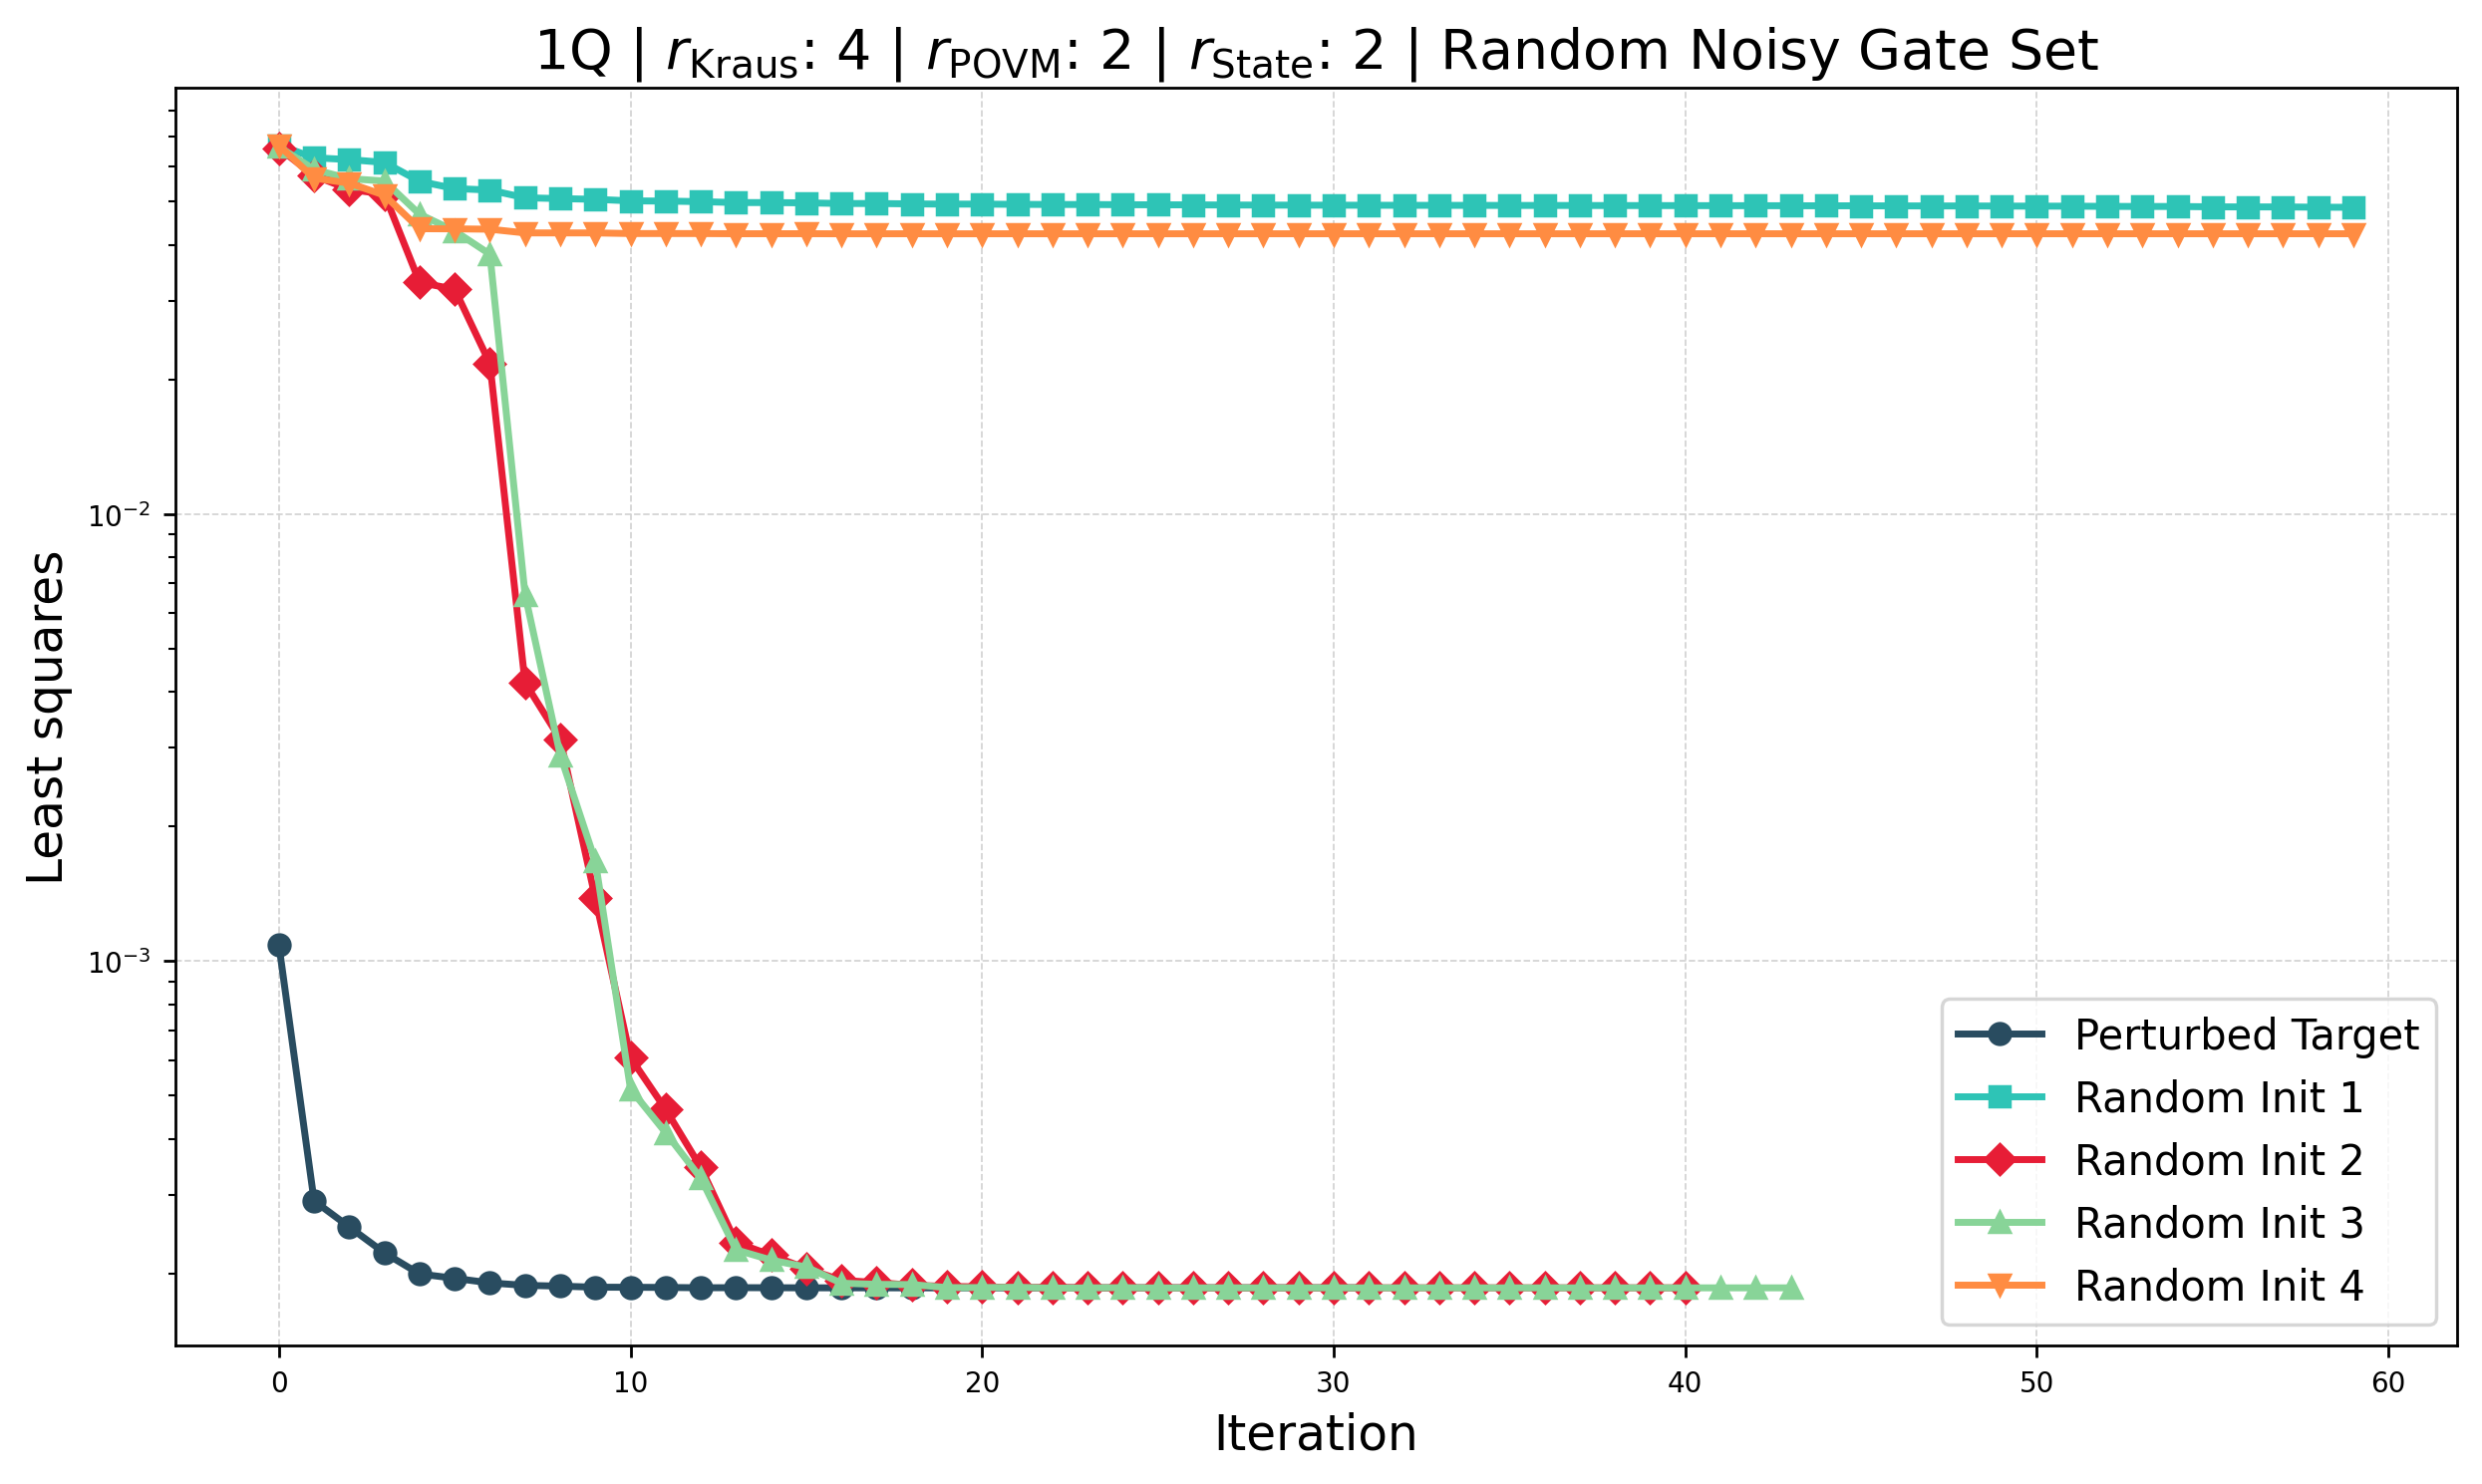

In [73]:
cost_fn_inits = [res["cost_fn_history"]["least_squares"] for res in optimization_results_init]

labels_init = ["Perturbed Target"] + [f"Random Init {i+1}" for i in range(random_inits+1)]

plot_cost_function(cost_fn_inits[:], title=title_init, labels=labels_init[:], ylabel="Least squares")

In [74]:
[cost[-1] for cost in cost_fn_inits]

[Array(0.00018554, dtype=float64),
 Array(0.0485346, dtype=float64),
 Array(0.00018554, dtype=float64),
 Array(0.00018554, dtype=float64),
 Array(0.0423497, dtype=float64)]